In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# for notebook 
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [3]:
def draw_graph_with_nx(G):
    pos = nx.spring_layout(G, iterations=200)
    options = {  'node_color': 'white', 'alpha': 1, 'node_size': 2000, 'width': 0.2,
                 'font_size': 25, 'arrows': True, 'edge_color': 'brown',
                 'arrowstyle': 'Fancy, head_length=1, head_width=1,  tail_width=.4',         
              }
    labels = nx.get_node_attributes(G, 'label')
    weight_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw(G, pos, labels= labels, **options)
    nx.draw_networkx_edge_labels(G, pos, edge_labels= weight_labels, font_size = 15 )
    plt.show()

In [4]:
class WeightedDigraph:
    def __init__(self):
        self.g = {}
        
    def add_node(self, node):
        if node in self.g:
            raise ValueError("Node already in graph")
        
        self.g[node] = []
        
    def add_edge(self, src, dest, weight):
        if src not in self.g:
            raise ValueError("Source node not in graph")
        if dest not in self.g: 
            raise ValueError("Destination node not in graph")
        
        nexts = self.g[src]
        if dest in nexts:
            return
        
        nexts.append((dest, weight))
        
        
    def draw_graph(self):
        G = nx.DiGraph()
        for src in self.g:
            G.add_node(src, label=src)
            for dest in self.g[src]:
                G.add_edge(src, dest[0], weight=str(dest[1]) )
                
        draw_graph_with_nx(G)

In [5]:
g = WeightedDigraph()

nodes = ['a','b','c','d','e','f']

for n in nodes:
    g.add_node(n)

edges = [
    ('a', 'b', 5),
    ('a', 'c', 1),
    ('b', 'c', 7),
    ('b', 'd', 8),
    ('c', 'd', 3),
    ('d', 'c', 4),
    ('e', 'f', 8),
    ('f', 'c', 7),
]

for e in edges:
    g.add_edge(e[0], e[1], e[2])

In [42]:
g = WeightedDigraph()

nodes = ['a','b','c','d','e']

for n in nodes:
    g.add_node(n)

edges = [
    ('a', 'b', 4),
    ('a', 'c', 1),
    ('b', 'd', 8),
    ('c', 'e', 25),
    ('e', 'd', 3),
]

for e in edges:
    g.add_edge(e[0], e[1], e[2])

In [51]:
g = WeightedDigraph()

nodes = ['a','b','c','d','e','f','g','h']

for n in nodes:
    g.add_node(n)

edges = [
    ('a', 'b', 4),
    ('a', 'c', 1),
    ('b', 'd', 8),
    ('c', 'e', 25),
    ('e', 'd', 3),
    ('d', 'f', 5),
    ('d', 'g', 7),
    ('f', 'h', 2),      # remove this first
    ('g', 'h', 9),      # then this too
]

for e in edges:
    g.add_edge(e[0], e[1], e[2])

In [52]:
import pprint
pprint.pprint(g.g)

{'a': [('b', 4), ('c', 1)],
 'b': [('d', 8)],
 'c': [('e', 25)],
 'd': [('f', 5), ('g', 7)],
 'e': [('d', 3)],
 'f': [('h', 2)],
 'g': [('h', 9)],
 'h': []}


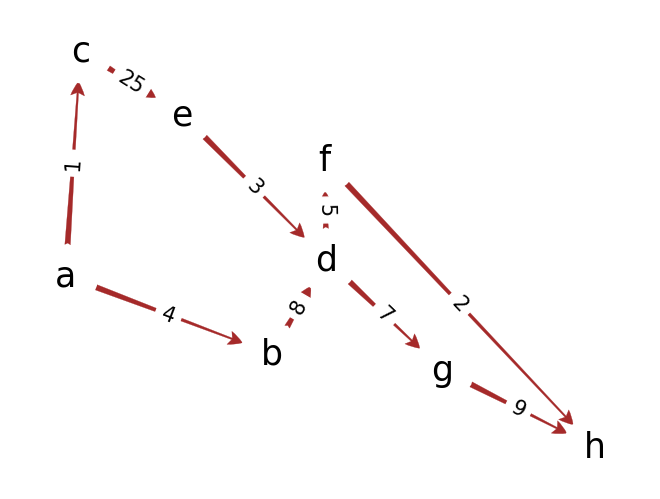

In [53]:
g.draw_graph()

In [54]:
def traverse_graph(self, start):
    """Traverse graph starting from given start node."""
    
    q = [start]
    visited = []
    
    while q:
        current = q.pop(0)
        
        # if we've already visited it, we can skip 
        if current in visited:
            continue
        
        print(current)
        
        # we're done with current
        visited.append(current)
        
        # get all directly connected nodes
        next_nodes = self.g[current]
        
        # traverse all the nexts
        for n in next_nodes:
            q.append(n[0])      # get node only instead of (dest, weight)
            
WeightedDigraph.traverse_graph = traverse_graph

In [55]:
g.traverse_graph('a')

a
b
c
d
e
f
g
h


# **Shortest Path - Dijkstra's Algorithm**

In [56]:
# Pronuciation of Dijkstra:  https://forvo.com/word/dijktra/#nl

In [57]:
def find_shortest_dijkstra(self, src):
    # Mark all nodes unvisited and store them.
    to_visit = list(self.g.keys() )
    
    print("To visit: "+ str(to_visit))
    
    # Set the distance to zero for our initial node and to infinity for other nodes.
    inf = float('inf')      # that's python for infinity
    dists = { node: inf for node in to_visit}
    dists[src] = 0
    print("All distances" + str(dists))
    
    
    # let's loop
    while to_visit:
        print("---------")
        
        # Select the universal node with the smallest distance
        # can't compare 'a' with 'b'. So, we compare dists['a'] with dists['b']
        current = min(to_visit, key=lambda node: dists[node])
        print("Current: " + current)
        
        # current is now visited
        to_visit.remove(current)
        
        # check to make sure min distance isn't infinity
        if dists[current] == inf:
            break
        
        # Find unvisited neighbors for the current node
        nexts = self.g[current]
        unvisited_neighbors = []
        for n in nexts:
            if n[0] in to_visit:    # recall that n is e.g. ('b', 5)
                unvisited_neighbors.append(n)
                
        print("Unvisited neighbors of "+ current + ": " + str(unvisited_neighbors))
        
        
        # calculate their distances through the current node 
        for n in unvisited_neighbors:
            label = n[0]
            dist_to = n[1]
            
            old_distance = dists[label]
            new_distance = dists[current] + dist_to
            
            # See which is better: old best distance or this one
            if new_distance < old_distance:
                dists[label] = new_distance
                
                
        print("All distances" + str(dists))
            
        
        # break         # break after each iteration for demo
            

WeightedDigraph.find_shortest_dijkstra = find_shortest_dijkstra            

In [58]:
g.find_shortest_dijkstra('a')

To visit: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
All distances{'a': 0, 'b': inf, 'c': inf, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
---------
Current: a
Unvisited neighbors of a: [('b', 4), ('c', 1)]
All distances{'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
---------
Current: c
Unvisited neighbors of c: [('e', 25)]
All distances{'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': 26, 'f': inf, 'g': inf, 'h': inf}
---------
Current: b
Unvisited neighbors of b: [('d', 8)]
All distances{'a': 0, 'b': 4, 'c': 1, 'd': 12, 'e': 26, 'f': inf, 'g': inf, 'h': inf}
---------
Current: d
Unvisited neighbors of d: [('f', 5), ('g', 7)]
All distances{'a': 0, 'b': 4, 'c': 1, 'd': 12, 'e': 26, 'f': 17, 'g': 19, 'h': inf}
---------
Current: f
Unvisited neighbors of f: [('h', 2)]
All distances{'a': 0, 'b': 4, 'c': 1, 'd': 12, 'e': 26, 'f': 17, 'g': 19, 'h': 19}
---------
Current: g
Unvisited neighbors of g: [('h', 9)]
All distances{'a': 0, 'b': 4, 'c': 1, 'd': 12, 'e': 26, 'f':

In [59]:
def find_shortest_dijkstra(self, src, dest):
    # Mark all nodes unvisited and store them.
    to_visit = list(self.g.keys() )
    
    print("To visit: "+ str(to_visit))
    
    # Set the distance to zero for our initial node and to infinity for other nodes.
    inf = float('inf')      # that's python for infinity
    dists = { node: inf for node in to_visit}
    dists[src] = 0
    print("All distances" + str(dists))
    
    best_paths = {}
    best_paths[(src, src)] = [src]      #no move
    
    # let's loop
    while to_visit:
        print("---------")
        
        # Select the universal node with the smallest distance
        # can't compare 'a' with 'b'. So, we compare dists['a'] with dists['b']
        current = min(to_visit, key=lambda node: dists[node])
        print("Current: " + current)
        
        # the same thing is done down
        # # current is now visited
        # to_visit.remove(current)
        
        # check to make sure min distance isn't infinity
        if dists[current] == inf:
            break
        
        # Find unvisited neighbors for the current node
        nexts = self.g[current]
        unvisited_neighbors = []
        for n in nexts:
            if n[0] in to_visit:    # recall that n is e.g. ('b', 5)
                unvisited_neighbors.append(n)
                
        print("Unvisited neighbors of "+ current + ": " + str(unvisited_neighbors))
        
        
        # calculate their distances through the current node 
        for n in unvisited_neighbors:
            label = n[0]
            dist_to = n[1]
            
            # get old best distance and new distance
            old_distance = dists[label]
            new_distance = dists[current] + dist_to
            
            # see if we are improving on old best
            if new_distance < old_distance:
                print("\nFound new best path ... ")
                dists[label] = new_distance
                
                # also save path
                # best way to get from src to label is src->current->label
                path_to_current = best_paths[(src, current)][:]     # need a copy
                best_paths[(src, label)] = path_to_current
                best_paths[(src, label)].append(label)
                print("Previous best path to current: ", best_paths[(src, current)])
                print("Best path to:", label, ": ", best_paths[(src, label)])
                
        print("All distances" + str(dists))
            
        
        # current is now visited
        to_visit.remove(current)
        
        # break         # break after each iteration for demo
        
    return best_paths[(src, dest)], dists[dest]

WeightedDigraph.find_shortest_dijkstra = find_shortest_dijkstra            

In [60]:
g.find_shortest_dijkstra('a', 'd')

To visit: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
All distances{'a': 0, 'b': inf, 'c': inf, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
---------
Current: a
Unvisited neighbors of a: [('b', 4), ('c', 1)]

Found new best path ... 
Previous best path to current:  ['a']
Best path to: b :  ['a', 'b']

Found new best path ... 
Previous best path to current:  ['a']
Best path to: c :  ['a', 'c']
All distances{'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
---------
Current: c
Unvisited neighbors of c: [('e', 25)]

Found new best path ... 
Previous best path to current:  ['a', 'c']
Best path to: e :  ['a', 'c', 'e']
All distances{'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': 26, 'f': inf, 'g': inf, 'h': inf}
---------
Current: b
Unvisited neighbors of b: [('d', 8)]

Found new best path ... 
Previous best path to current:  ['a', 'b']
Best path to: d :  ['a', 'b', 'd']
All distances{'a': 0, 'b': 4, 'c': 1, 'd': 12, 'e': 26, 'f': inf, 'g': inf, 'h': inf}
---------
Curre

(['a', 'b', 'd'], 12)

In [61]:
g.find_shortest_dijkstra('a', 'h')

To visit: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
All distances{'a': 0, 'b': inf, 'c': inf, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
---------
Current: a
Unvisited neighbors of a: [('b', 4), ('c', 1)]

Found new best path ... 
Previous best path to current:  ['a']
Best path to: b :  ['a', 'b']

Found new best path ... 
Previous best path to current:  ['a']
Best path to: c :  ['a', 'c']
All distances{'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': inf, 'f': inf, 'g': inf, 'h': inf}
---------
Current: c
Unvisited neighbors of c: [('e', 25)]

Found new best path ... 
Previous best path to current:  ['a', 'c']
Best path to: e :  ['a', 'c', 'e']
All distances{'a': 0, 'b': 4, 'c': 1, 'd': inf, 'e': 26, 'f': inf, 'g': inf, 'h': inf}
---------
Current: b
Unvisited neighbors of b: [('d', 8)]

Found new best path ... 
Previous best path to current:  ['a', 'b']
Best path to: d :  ['a', 'b', 'd']
All distances{'a': 0, 'b': 4, 'c': 1, 'd': 12, 'e': 26, 'f': inf, 'g': inf, 'h': inf}
---------
Curre

(['a', 'b', 'd', 'f', 'h'], 19)